In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load historical loan data - 20 past decisions
defaults = pd.read_csv('loan_defaults.csv')
print('Dataset shape:', defaults.shape)
print()
defaults.head(8)

Dataset shape: (150, 4)



,income,debt_ratio,num_late_payments,defaulted
0,877933,0.25,3,0
1,292175,0.20,1,0
2,346524,0.43,8,1
3,289362,0.17,10,1
4,42544,0.73,0,1
5,561299,0.19,3,0
6,571958,0.85,6,0
7,377098,0.14,8,1


In [2]:
# Separate features (X) from the label (y)
# Features = what we know about the applicant
# Label    = the outcome we want to predict

X = defaults[['income', 'debt_ratio', 'num_late_payments']]
y = defaults['defaulted']

print('Features (X) - 4 columns, 150 rows:')
print(X.head(4))
print()
print('Label (y) - what we want to predict:')
print(y.values)
print(f'Approved: {y.sum()} | Rejected: {(y==0).sum()}')

Features (X) - 4 columns, 150 rows:
   income  debt_ratio  num_late_payments
0  877933        0.25                  3
1  292175        0.20                  1
2  346524        0.43                  8
3  289362        0.17                 10

Label (y) - what we want to predict:
[0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0 1 0
 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1
 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0
 1 1 1 1 1 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 0
 1 1]
Approved: 104 | Rejected: 46


In [ ]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train)} defaulters')
print(f'Test set:     {len(X_test)} defaulters')
print()

# Train the ML model - it learns the rules from training data
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)   # <-- this is where learning happens

print('Model trained. It has now seen', len(X_train), 'examples.')
print('It learned patterns - no rules were written by hand.')

Training set: 120 applicants
Test set:     30 applicants

Model trained. It has now seen 120 examples.
It learned patterns - no rules were written by hand.


In [4]:
# Evaluate on test set - applicants the model has NEVER seen
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Test set predictions vs actual decisions:')
print(f'{"Actual":<10} {"ML Predicted":<15} {"Match?"}')
print('-' * 35)
for actual, predicted in zip(y_test, y_pred):
    match = 'YES' if actual == predicted else 'NO'
    label_a = 'APPROVED' if actual    else 'REJECTED'
    label_p = 'APPROVED' if predicted else 'REJECTED'
    print(f'{label_a:<10} {label_p:<15} {match}')

print()
print(f'Accuracy: {accuracy*100:.0f}%')

Test set predictions vs actual decisions:
Actual     ML Predicted    Match?
-----------------------------------
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
REJECTED   APPROVED        NO
REJECTED   REJECTED        YES
APPROVED   REJECTED        NO
REJECTED   REJECTED        YES
REJECTED   REJECTED        YES
APPROVED   REJECTED        NO
APPROVED   APPROVED        YES
APPROVED   REJECTED        NO
REJECTED   APPROVED        NO
APPROVED   APPROVED        YES
REJECTED   APPROVED        NO
APPROVED   APPROVED        YES
REJECTED   APPROVED        NO
APPROVED   APPROVED        YES
APPROVED   REJECTED        NO
APPROVED   APPROVED        YES
REJECTED   APPROVED        NO
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
REJECTED   APPROVED        NO
REJECTED   REJECTED        YES
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
APPROVED   APPROVED        YES
REJECTED   REJECTED        YES
APPROVED   REJECTED        NO


In [5]:
print('Supervised Learning - loan Prediction Results:')
print('Test accuracy:', round(accuracy * 100), '%')
print()
print('Predictions vs Actual:')

# Turn y_test into a normal list so we can count through it with a number
actual_list = list(y_test)

# Go through each customer one at a time, using a simple counter (i)
for i in range(len(actual_list)):
    actual_value = actual_list[i]
    predicted_value = y_pred[i]

    if actual_value == 1:
        actual_text = 'approved'
    else:
        actual_text = 'rejected'

    if predicted_value == 1:
        predicted_text = 'approved'
    else:
        predicted_text = 'rejected'

    if actual_value == predicted_value:
        result = 'correct'
    else:
        result = 'wrong'

    print('Customer', i + 1, '-> Actual:', actual_text, '| Predicted:', predicted_text, '| Model was', result)

Supervised Learning - loan Prediction Results:
Test accuracy: 63 %

Predictions vs Actual:
Customer 1 -> Actual: approved | Predicted: approved | Model was correct
Customer 2 -> Actual: approved | Predicted: approved | Model was correct
Customer 3 -> Actual: rejected | Predicted: approved | Model was wrong
Customer 4 -> Actual: rejected | Predicted: rejected | Model was correct
Customer 5 -> Actual: approved | Predicted: rejected | Model was wrong
Customer 6 -> Actual: rejected | Predicted: rejected | Model was correct
Customer 7 -> Actual: rejected | Predicted: rejected | Model was correct
Customer 8 -> Actual: approved | Predicted: rejected | Model was wrong
Customer 9 -> Actual: approved | Predicted: approved | Model was correct
Customer 10 -> Actual: approved | Predicted: rejected | Model was wrong
Customer 11 -> Actual: rejected | Predicted: approved | Model was wrong
Customer 12 -> Actual: approved | Predicted: approved | Model was correct
Customer 13 -> Actual: rejected | Predic

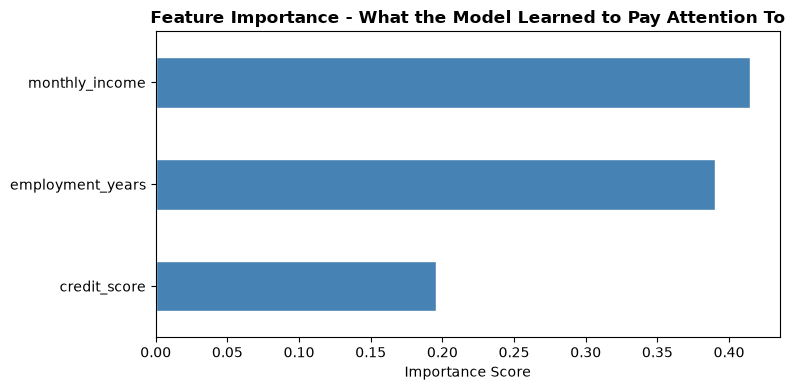

The model assigned importance to each feature based on the training data.
This is the pattern it learned - no human specified these weights.


In [6]:
import matplotlib.pyplot as plt

# Feature importance - which feature mattered most to the model?
importance = pd.Series(
    model.feature_importances_,
    index=['monthly_income', 'credit_score', 'employment_years']
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance - What the Model Learned to Pay Attention To',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('The model assigned importance to each feature based on the training data.')
print('This is the pattern it learned - no human specified these weights.')